### Bibliotecas utilizadas

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


### Dataset creditcard.csv

* As colunas de V1 a V28 foram anonimizadas por questões de confidencialidade e privacidade dos titulares, o Google/Kaggle aplicou uma técnica de Machine Learning chamada Análise de Componentes Principais (PCA). Elas representam atributos complexos da transação (como localização, IP, tipo de vendedor).

* Class: variável que se tenta prever.

(Encontrar padrões que diferencie operações normais de operações fraudelentas)

In [24]:
URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df_creditcard = pd.read_csv(URL)
df_creditcard.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Verificando a proporção de cada tipo da transação (fraude e não fraude)

- Aqui foi verificado que o dataset é desbalanceado
Este arquivo **creditcard.csv** é famoso na ciência de dados justamente por ser altamente desbalanceado. Menos de \(0{,}17\%\) do total de registros são fraudes, o que exige técnicas especiais para treinar modelos de Inteligência Artificial sem que eles apenas "adivinhem" tudo como transação normal.

- Como as fraudes são raras: o modelo pode ignorar a classe 1.
- Desbalanceamento: Quando uma classe aparece mais do que agora, no caso, há muito mais exemplos de não fraude.
- O modelo pode aprender errado e nunca detectar as fraudes.
- Acurácia: porcentagem de acertos do modelo.
- Neste caso, a acurária será alta mas será enganosa. Portanto em problemas desbalanceados devemos usar outras métricas, como Recall.
- Recall: mede quantas fraudes o modelo consegue identificar.
- Precision: mede se o que o modelo apontou como uma fraude é realmente fraude.

In [25]:
# Calculando proporção de cada tipo de transação.
df_creditcard['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### Feature Engineering
- Quando criamos/ou transformamos variáveis que ajudam o modelo a aprender melhor. Melhoram a análise e desempenho do modelo.
- Features: Variáveis do dataset.

### Utilizando log

- Os valores das transações financeiras em *Amount* variam muito e essa diferença enorme de escala atrapalha o modelo, pois ele tende a dar muito mais importância para números grandes. 
- Usando o ***np.log1p***: Aplicamos uma transformação logarítmica que comprime esses valores, deixando-os mais próximos entre si, tornando esses valores mais equilibrados.
- Essa técnica é comumente utilizada em dados financeiros justamente pelo fato dos valores de transações costumarem ter uma variação enorme.

In [26]:
df_creditcard['Amount_log'] = np.log1p(df_creditcard['Amount'])

### Padronizando alguns dados

- Ajustamdo os dados para uma escala comum (melhorar o desempenho do modelo)
- Transforma os dados para que tenha a Média: 0 e o Desvio Padrão: 1.
- Na prática: Os valores ficam na mesma escala e os variáveis passam a ter o mesmo peso.

In [27]:
scaler = StandardScaler()
df_creditcard['Amount_Scaled'] = scaler.fit_transform(df_creditcard[['Amount']])

In [28]:
df_creditcard.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Amount_Scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,-0.073403


### Preparando os dados para o treinamento do modelo

- x:representa todas as features/ variáveis de entrada (menos a Class)
- axis=1 trabalha nas colunas/ na direção das linhas/ desce ↓
- y: representa o nosso target/ o que queremos prever
- 30% do dados vão para teste/ o restante para treino
- random: garantir que a divisão seja sempre a mesma sempre que o código for rodado 
- stratify: garanti que a proporção de fraudes e de não fraudes sejam mantidas (tanto no teste quanto no treino (desbalanceado))

In [29]:
x = df_creditcard.drop("Class", axis=1)
y = df_creditcard['Class']

x_train, x_test, y_train, y_test = train_test_split(  
    x, y, stratify=y, test_size=0.3, random_state=42
)

### Regressão Logística

- Modelo de classificação usado para prever categorias, aqui no exemplo: prever se é fraude(1) ou não fraude(0).
- Um dos modelos mais simples, geralmente utilizado inicialmente e serve como referência para outros modelos que possam vir a ser utilizados.

Após rodar foi dado uma aviso: significa que o modelo não conseguiu terminar de aprender dentro do limite de tentativas definido (1000 iterações).
   Para resolver: aumentar o número de iterações ((max_iter=5000)) OU escalar ps dados (usar o código abaixo antes do modelo):
            
            scaler = StandardScaler()
            x_train_scaled = scaler.fit_transform(x_train)
            x_test_scaled = scaler.transform(x_test) 

In [30]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)   

c:\Taita Geral\1. CURSOS\Dio_Bootcamp_Accenture_2026\Projeto_Deteccao_Fraudes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# Verificando como o modelo se saiu mesmo com aviso:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.67      0.75       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### Entendendo o resultado do modelo:

As colunas:
    
    - Precision: Das vezes que o modelo disse "é fraude", quantas eram de fato fraude?
    - Recall: Das fraudes reais, quantas o modelo conseguiu detectar?
    - F1-score: Média entre precision e recall (nota geral)
    - Support: Quantidade real de casos

As linhas:
    
    - Classe 0 (transação normal) — 85.295 casos
    - O modelo foi perfeito — acertou todas as transações normais. ✅
    - Classe 1 (fraude) — 148 casos

    - Precision 0.85 → quando disse "é fraude", acertou 85% das vezes ✅
    - Recall 0.67 → das 148 fraudes reais, detectou apenas 67% ⚠️
    - Ou seja, deixou passar ~33% das fraudes sem detectar

⚠️O modelo acertou quase tudo porque 99% dos dados são transações normais. Ele "aprendeu" que o mais seguro é dizer "normal" — e quase sempre acerta.
Mas no contexto de detecção de fraude, o Recall da classe 1 é o mais importante — e 0.67 significa que 1 em cada 3 fraudes passou despercebida.

Resumindo:

    - Transações normais → 🟢 Perfeito
    - Detecção de fraudes → 🟡 Razoável, pode melhorar

⚠️ Isso é muito comum em datasets desbalanceados (como é o caso). 

### Métrica: Curva ROC

- Métrica importante utilizada em modelos de classificação.
- False Positive Rate: Taxa de falsos positivos, quantas transações normais foram classificadas como fraude.
- True Positive Rate: Quantas fraudes o modelo realmente identificou.
- Quanto mais a curva se aproxima do canto superior esquerdo, melhor é o modelo: alto recall e baixo erro.
- Se a curva for uma linha reta diagonal o modelo seria aleatório, não seria capaz de distinguir fraude ou não fraude.
- AUC: Valor próximo de 1 indica que o modelo está muito bom, próximo a 0.5 modelo aleatório.

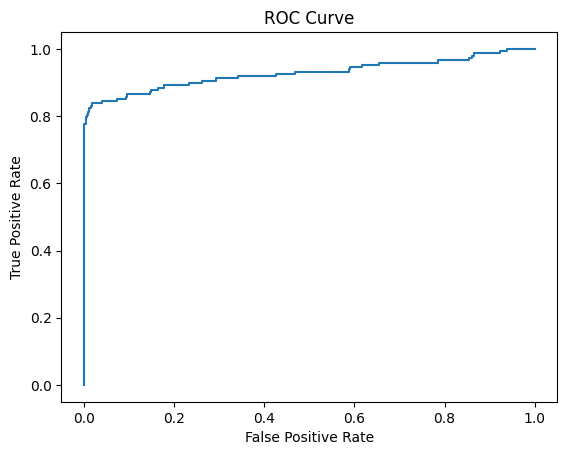

AUC: 0.9273972049310582


In [33]:
y_probs = model.predict_proba(x_test)[:,1]
fpr, tpr, _ =roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

### Métrica: Precision-Recall Curve

- Métrica mais importante utilizada em datasets desbalanceados como neste de fraude.
- Recall: quantas fraudes o modelo consegue identificar.
- Precision: quantas fraudes são realmente fraudes.



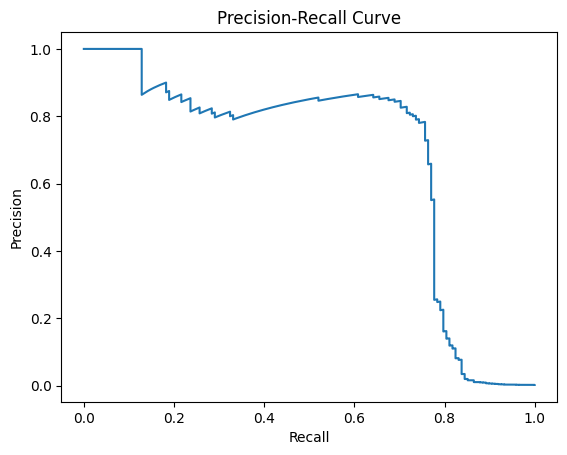

In [36]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Formas de atuar em datasets com dados desbalanceados

### Undersampling

- Cria um dataset equilibrado, com a mesma quantidade de transações normais e fraudes.
- A classe majoritário (no caso, classe de transações normais) é reduzida para o mesmo tamanho da classe minoritária (classe de transações de fraudes).
- Problema: Perda de muitos dados normais, reduzindo a qualidade dos dados.

In [ ]:
fraudes = df_creditcard[df_creditcard["Class"]==1]
normais = df_creditcard[df_creditcard["Class"]==0].sample(len(fraudes), random_state=42)

df_creditcard_under = pd.concat([fraudes, normais])

In [ ]:
print(f"Dimensão do Dataset original: {df_creditcard.shape}")
print(f"Dimensão do Dataset undersampling: {df_creditcard_under.shape}")

Dimensão do Dataset original: (284807, 33)
Dimensão do Dataset undersampling: (984, 33)


### Oversampling

- Também cria um dataset equilibrado, com a mesma quantidade de transações normais e fraudes.
- Cria novos exemplos sintéticos da classe minoritária (trasações fraudes).
- Gera novos dados (novas fraudes) baseadas nas já existentes.
- Ponto positivo: Não há perda de dados, e a representação da classe minoritária aumenta.
- Ponto negativo: Dados gerados são artificiais.

In [48]:
smote = SMOTE()
x_res, y_res = smote.fit_resample(x, y)

In [49]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443

